# AI Benchmark Data Analysis — Open LLM Leaderboard
**Goal:** treat the leaderboard like a benchmark report under review: validate the data, find trends, correlations and anomalies, then explain them to a non-technical reader.

**Data source:** Hugging Face dataset `open-llm-leaderboard/contents` (the leaderboard is archived, so check the dataset is still available; otherwise use a Kaggle copy and change the loading cell).

In [1]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

MIN_PARAMS = 0.01   # in billions; below this the reported size is treated as suspicious
sns.set_theme(style="whitegrid", context="notebook")
os.makedirs("images", exist_ok=True)
pd.set_option("display.max_columns", 50, "display.width", 200)

## 1) Load the data

In [2]:
from datasets import load_dataset
df = load_dataset("open-llm-leaderboard/contents", split="train").to_pandas()

# Fallback (Kaggle / local copy):
# df = pd.read_csv("open_llm_leaderboard.csv")

print(df.shape)
print(df.columns.tolist())
df.head(3)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(4576, 36)
['eval_name', 'Precision', 'Type', 'T', 'Weight type', 'Architecture', 'Model', 'fullname', 'Model sha', 'Average ⬆️', 'Hub License', 'Hub ❤️', '#Params (B)', 'Available on the hub', 'MoE', 'Flagged', 'Chat Template', 'CO₂ cost (kg)', 'IFEval Raw', 'IFEval', 'BBH Raw', 'BBH', 'MATH Lvl 5 Raw', 'MATH Lvl 5', 'GPQA Raw', 'GPQA', 'MUSR Raw', 'MUSR', 'MMLU-PRO Raw', 'MMLU-PRO', 'Merged', 'Official Providers', 'Upload To Hub Date', 'Submission Date', 'Generation', 'Base Model']


,eval_name,Precision,Type,T,Weight type,Architecture,Model,fullname,Model sha,Average ⬆️,Hub License,Hub ❤️,#Params (B),Available on the hub,MoE,Flagged,Chat Template,CO₂ cost (kg),IFEval Raw,IFEval,BBH Raw,BBH,MATH Lvl 5 Raw,MATH Lvl 5,GPQA Raw,GPQA,MUSR Raw,MUSR,MMLU-PRO Raw,MMLU-PRO,Merged,Official Providers,Upload To Hub Date,Submission Date,Generation,Base Model
0,0-hero_Matter-0.2-7B-DPO_bfloat16,bfloat16,"💬 chat models (RLHF, DPO, IFT, ...)",💬,Original,MistralForCausalLM,"<a target=""_blank"" href=""https://huggingface.c...",0-hero/Matter-0.2-7B-DPO,26a66f0d862e2024ce4ad0a09c37052ac36e8af6,8.906361,apache-2.0,3,7.242,True,False,False,True,1.219174,0.330279,33.027921,0.359625,10.055525,0.014350,1.435045,0.259228,1.230425,0.381375,5.871875,0.116356,1.817376,False,False,2024-04-13,2024-08-05,0,0-hero/Matter-0.2-7B-DPO
1,01-ai_Yi-1.5-34B_bfloat16,bfloat16,🟢 pretrained,🟢,Original,LlamaForCausalLM,"<a target=""_blank"" href=""https://huggingface.c...",01-ai/Yi-1.5-34B,4b486f81c935a2dadde84c6baa1e1370d40a098f,25.646494,apache-2.0,46,34.389,True,False,False,False,22.703398,0.284117,28.411725,0.597639,42.749363,0.153323,15.332326,0.365772,15.436242,0.423604,11.217188,0.466589,40.732122,False,True,2024-05-11,2024-06-12,0,01-ai/Yi-1.5-34B
2,01-ai_Yi-1.5-34B-32K_bfloat16,bfloat16,🟢 pretrained,🟢,Original,LlamaForCausalLM,"<a target=""_blank"" href=""https://huggingface.c...",01-ai/Yi-1.5-34B-32K,2c03a29761e4174f20347a60fbe229be4383d48b,26.727913,apache-2.0,36,34.389,True,False,False,False,23.154629,0.311869,31.186917,0.601569,43.381847,0.154079,15.407855,0.363255,15.100671,0.439823,14.077865,0.470911,41.212323,False,True,2024-05-15,2024-06-12,0,01-ai/Yi-1.5-34B-32K


### Column mapping
Column names can differ between versions, so I detect them by keyword instead of hard-coding. **Check the printed mapping before moving on.**

In [3]:
def find_col(df, keyword, exclude=("raw",)):
    for c in df.columns:
        lc = c.lower()
        if keyword.lower() in lc and not any(e in lc for e in exclude):
            return c
    return None

BENCH_KEYS = ["IFEval", "BBH", "MATH", "GPQA", "MUSR", "MMLU-PRO"]
bench = [find_col(df, k) for k in BENCH_KEYS]
bench = [b for b in bench if b is not None]

avg_col    = find_col(df, "average")
params_col = find_col(df, "params")
type_col   = find_col(df, "type", exclude=("raw", "weight"))
name_col   = find_col(df, "fullname") or find_col(df, "model")

print("Benchmarks:", bench)
print("Average   :", avg_col)
print("Params    :", params_col)
print("Type      :", type_col)
print("Name      :", name_col)

Benchmarks: ['IFEval', 'BBH', 'MATH Lvl 5', 'GPQA', 'MUSR', 'MMLU-PRO']
Average   : Average ⬆️
Params    : #Params (B)
Type      : Type
Name      : fullname


## 2) Data Integrity Checks

In [4]:
raw = df.copy()
issues = []

# 1) Wrong dtypes (numbers stored as text)
bad_dtype = 0
for c in bench + [avg_col, params_col]:
    if not pd.api.types.is_numeric_dtype(raw[c]):
        converted = pd.to_numeric(raw[c], errors="coerce")
        bad_dtype += int((converted.isna() & raw[c].notna()).sum())
        raw[c] = converted
issues.append(("Numeric columns stored as text", bad_dtype, "Converted with pd.to_numeric(errors='coerce')"))

# 2) Missing values
n_missing = int(raw[bench + [avg_col]].isna().any(axis=1).sum())
issues.append(("Rows with missing benchmark/average scores", n_missing, "Excluded from the clean dataset"))

# 3) Duplicate models
n_dups = int(raw.duplicated(subset=[name_col]).sum())
issues.append(("Duplicate model names", n_dups, "Kept first occurrence"))

# 4) Score range 0-100
out_range = int(((raw[bench] < 0) | (raw[bench] > 100)).any(axis=1).sum())
issues.append(("Rows with scores outside 0-100", out_range, "Excluded from the clean dataset"))

# 5) Recompute Average and compare to the reported one
recomputed = raw[bench].mean(axis=1)
diff = (recomputed - raw[avg_col]).abs()
n_avg_diff = int((diff > 0.01).sum())
issues.append(("Reported Average differs from recomputed (>0.01)", n_avg_diff, "Logged; recomputed Average used where it matters"))

# 6) Non-positive or missing size
n_size = int((~(raw[params_col] > 0)).sum())
issues.append(("Rows with missing/non-positive Params", n_size, "Excluded from size analysis only"))

# 7) Suspiciously small size (reported size implausible for an LLM)
n_tiny = int(((raw[params_col] > 0) & (raw[params_col] < MIN_PARAMS)).sum())
issues.append((f"Suspiciously small Params (<{MIN_PARAMS}B)", n_tiny, "Excluded from size/anomaly analysis; likely reporting error"))

integrity = pd.DataFrame(issues, columns=["Check", "Issues found", "Action taken"])
integrity

,Check,Issues found,Action taken
0,Numeric columns stored as text,0,Converted with pd.to_numeric(errors='coerce')
1,Rows with missing benchmark/average scores,0,Excluded from the clean dataset
2,Duplicate model names,79,Kept first occurrence
3,Rows with scores outside 0-100,0,Excluded from the clean dataset
4,Reported Average differs from recomputed (>0.01),0,Logged; recomputed Average used where it matters
5,Rows with missing/non-positive Params,10,Excluded from size analysis only
6,Suspiciously small Params (<0.01B),2,Excluded from size/anomaly analysis; likely re...


In [5]:
clean = raw.drop_duplicates(subset=[name_col]).dropna(subset=bench + [avg_col]).copy()
clean = clean[((clean[bench] >= 0) & (clean[bench] <= 100)).all(axis=1)].copy()
clean["avg_recomputed"] = clean[bench].mean(axis=1)

print(f"Raw records: {len(raw):,} -> clean records: {len(clean):,}")

# Look at the biggest Average mismatches (if any)
mismatch = clean.assign(avg_diff=(clean["avg_recomputed"] - clean[avg_col]).abs())
mismatch.sort_values("avg_diff", ascending=False)[[name_col, avg_col, "avg_recomputed", "avg_diff"]].head(10)

Raw records: 4,576 -> clean records: 4,497


,fullname,Average ⬆️,avg_recomputed,avg_diff
0,0-hero/Matter-0.2-7B-DPO,8.906361,8.906361,0.0
3047,jaspionjader/bh-35,24.218719,24.218719,0.0
3053,jaspionjader/bh-40,24.130851,24.130851,0.0
3052,jaspionjader/bh-4,24.273262,24.273262,0.0
3051,jaspionjader/bh-39,24.313151,24.313151,0.0
3050,jaspionjader/bh-38,24.065233,24.065233,0.0
3049,jaspionjader/bh-37,24.412458,24.412458,0.0
3048,jaspionjader/bh-36,24.500646,24.500646,0.0
3046,jaspionjader/bh-34,24.075219,24.075219,0.0
3055,jaspionjader/bh-42,24.232844,24.232844,0.0


## 3) EDA & Statistics

In [6]:
clean[bench].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
IFEval,4497.0,45.66,20.48,0.00,27.78,45.22,62.83,89.98
BBH,4497.0,27.67,15.22,0.25,16.49,29.53,36.44,76.70
MATH Lvl 5,4497.0,15.62,14.66,0.00,4.38,10.80,22.13,71.45
GPQA,4497.0,6.73,5.08,0.00,2.68,5.93,9.28,29.42
MUSR,4497.0,9.99,5.84,0.00,5.09,10.03,13.62,38.69
MMLU-PRO,4497.0,25.44,14.25,0.28,15.96,27.25,34.69,70.03


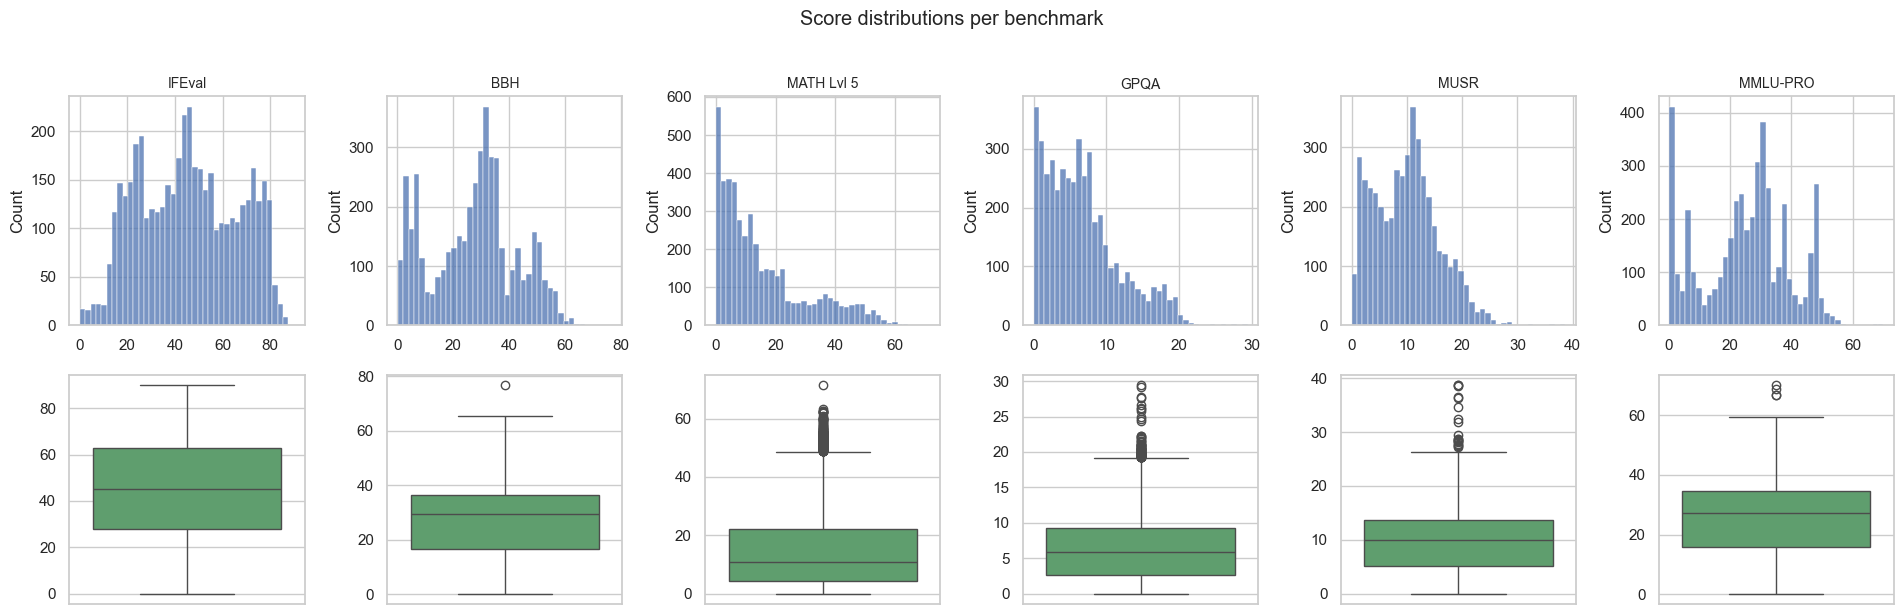

In [7]:
# Score distributions per benchmark
fig, axes = plt.subplots(2, len(bench), figsize=(3.2*len(bench), 6))
for i, b in enumerate(bench):
    sns.histplot(clean[b], bins=40, ax=axes[0, i], color="#4C72B0")
    axes[0, i].set_title(b, fontsize=10); axes[0, i].set_xlabel("")
    sns.boxplot(y=clean[b], ax=axes[1, i], color="#55A868")
    axes[1, i].set_ylabel("")
plt.suptitle("Score distributions per benchmark", y=1.02)
plt.tight_layout(); plt.show()

Most correlated : ('BBH', 'MMLU-PRO') 0.95
Least correlated: ('IFEval', 'MUSR') 0.37


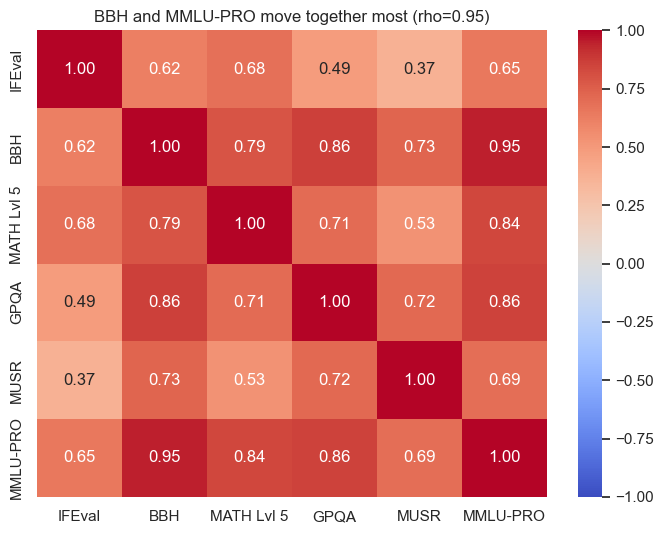

In [8]:
# Correlation between benchmarks
corr = clean[bench].corr(method="spearman")
pairs = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack().dropna().sort_values()
strongest, weakest = pairs.index[-1], pairs.index[0]
print("Most correlated :", strongest, round(pairs.iloc[-1], 2))
print("Least correlated:", weakest,   round(pairs.iloc[0], 2))

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title(f"{strongest[0]} and {strongest[1]} move together most (rho={pairs.iloc[-1]:.2f})")
plt.tight_layout(); plt.savefig("images/1_correlation.png", dpi=150); plt.show()

**Interpretation (from the run):** BBH and MMLU-PRO are almost interchangeable (Spearman rho = 0.95), so they largely measure the same thing. IFEval and MUSR are the least related pair (rho = 0.37): instruction-following is rewarded by chat/instruction tuning, while MUSR tests long multi-step reasoning, so a model can be good at one and weak at the other.

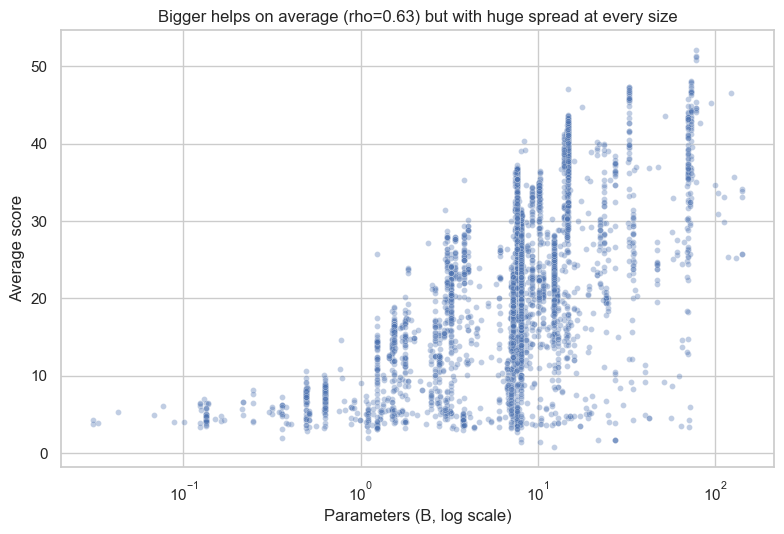

In [9]:
# Model size vs score
size = clean[clean[params_col] >= MIN_PARAMS].copy()
rho, p = stats.spearmanr(np.log10(size[params_col]), size[avg_col])

plt.figure(figsize=(8, 5.5))
sns.scatterplot(data=size, x=params_col, y=avg_col, alpha=0.35, s=18)
plt.xscale("log")
plt.xlabel("Parameters (B, log scale)"); plt.ylabel("Average score")
plt.title(f"Bigger helps on average (rho={rho:.2f}) but with huge spread at every size")
plt.tight_layout(); plt.savefig("images/2_size_vs_score.png", dpi=150); plt.show()

,count,median,max,median_gain_vs_prev
size_bin,,,,
<3B,778,7.83,31.48,NaN
3-7B,463,18.07,35.29,10.24
7-13B,2276,22.88,40.36,4.81
13-35B,770,36.77,47.37,13.89
35-80B,182,36.43,52.08,-0.34
>80B,16,33.39,46.52,-3.04


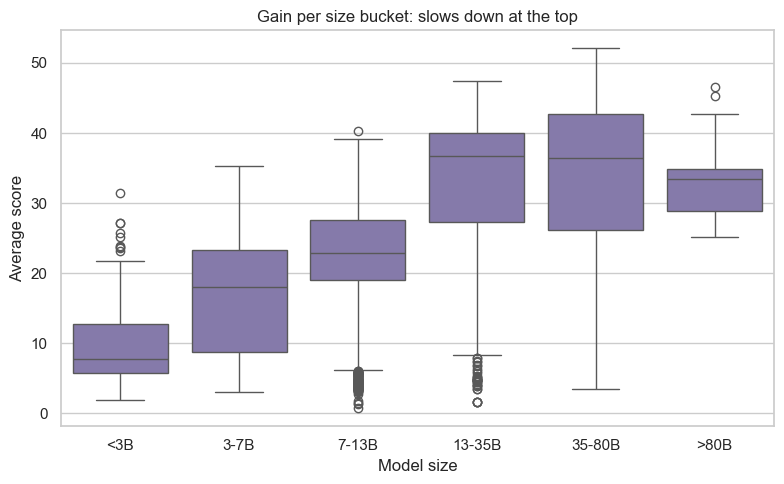

In [10]:
# Is the gain constant or does it flatten?
bins   = [0, 3, 7, 13, 35, 80, np.inf]
labels = ["<3B", "3-7B", "7-13B", "13-35B", "35-80B", ">80B"]
size["size_bin"] = pd.cut(size[params_col], bins=bins, labels=labels)
by_size = size.groupby("size_bin", observed=True)[avg_col].agg(["count", "median", "max"]).round(2)
by_size["median_gain_vs_prev"] = by_size["median"].diff().round(2)
display(by_size)

plt.figure(figsize=(8, 5))
sns.boxplot(data=size, x="size_bin", y=avg_col, color="#8172B2")
plt.title("Gain per size bucket: " + ("slows down at the top" if by_size["median_gain_vs_prev"].iloc[-1] < by_size["median_gain_vs_prev"].max() else "keeps growing"))
plt.xlabel("Model size"); plt.ylabel("Average score")
plt.tight_layout(); plt.savefig("images/3_size_buckets.png", dpi=150); plt.show()

Type
🔶 fine-tuned on domain-specific datasets    1752
🤝 base merges and moerges                   1712
💬 chat models (RLHF, DPO, IFT, ...)          695
🟢 pretrained                                 268
🟩 continuously pretrained                     56
🌸 multimodal                                   7
❓ other                                        7
Name: count, dtype: int64
model_group
Fine-tuned                  1752
Merged models               1712
Chat / instruction-tuned     695
Base / pretrained            324
Other                         14
Name: count, dtype: int64
model_group
Base / pretrained            8.5
Fine-tuned                  19.0
Chat / instruction-tuned    23.2
Merged models               24.4
Name: Average ⬆️, dtype: float64


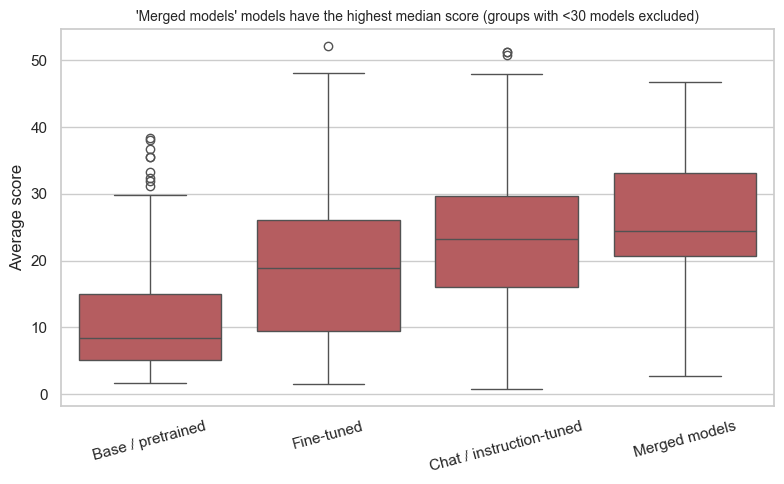

In [11]:
# Base vs fine-tuned
print(clean[type_col].value_counts())   # check the raw labels before grouping them

def simplify(t):
    t = str(t).lower()
    if "merge" in t: return "Merged models"          # must come before the "base" check
    if "pretrained" in t or "base" in t: return "Base / pretrained"
    if "chat" in t or "instruction" in t or "rlhf" in t: return "Chat / instruction-tuned"
    if "fine-tuned" in t or "finetuned" in t: return "Fine-tuned"
    return "Other"

clean["model_group"] = clean[type_col].map(simplify)
counts = clean["model_group"].value_counts()
print(counts)

# Only compare groups with enough models (tiny groups like "Other" can win a median by chance)
plot_df = clean[clean["model_group"].map(counts) >= 30]
order = plot_df.groupby("model_group")[avg_col].median().sort_values().index
print(plot_df.groupby("model_group")[avg_col].median().round(1).sort_values())

plt.figure(figsize=(8, 5))
sns.boxplot(data=plot_df, x="model_group", y=avg_col, order=order, color="#C44E52")
plt.xticks(rotation=15)
top = order[-1]
plt.title(f"'{top}' models have the highest median score (groups with <30 models excluded)", fontsize=10)
plt.xlabel(""); plt.ylabel("Average score")
plt.tight_layout(); plt.savefig("images/4_model_types.png", dpi=150); plt.show()

## 4) Anomaly Detection

In [12]:
# A) IQR outliers per benchmark
iqr_flags = pd.DataFrame(index=clean.index)
for b in bench:
    q1, q3 = clean[b].quantile([0.25, 0.75]); iqr = q3 - q1
    iqr_flags[b] = (clean[b] > q3 + 1.5*iqr) | (clean[b] < q1 - 1.5*iqr)
n_iqr_models = int(iqr_flags.any(axis=1).sum())
print("Models flagged by IQR in at least one benchmark:", n_iqr_models)
iqr_flags.sum().rename("outliers per benchmark")

Models flagged by IQR in at least one benchmark: 250


IFEval          0
BBH             1
MATH Lvl 5    181
GPQA           80
MUSR           19
MMLU-PRO        4
Name: outliers per benchmark, dtype: int64

In [13]:
# B) Small models that score much higher than expected for their size
size = clean[clean[params_col] >= MIN_PARAMS].copy()
slope, intercept = np.polyfit(np.log10(size[params_col]), size[avg_col], 1)
size["expected"] = intercept + slope*np.log10(size[params_col])
size["residual"] = size[avg_col] - size["expected"]
size["res_z"] = (size["residual"] - size["residual"].mean()) / size["residual"].std()

small_overperf = size[(size[params_col] <= 7) & (size["res_z"] > 3)]
print("Small models (<=7B) with residual z > 3:", len(small_overperf))
small_overperf.sort_values("res_z", ascending=False)[[name_col, params_col, avg_col, "expected", "res_z"]].head(15).round(2)

Small models (<=7B) with residual z > 3: 0


,fullname,#Params (B),Average ⬆️,expected,res_z


In [14]:
# C) High in one benchmark, very low in another (z-score spread across benchmarks)
z = (clean[bench] - clean[bench].mean()) / clean[bench].std()
clean["z_spread"] = z.max(axis=1) - z.min(axis=1)
clean["best_in"]  = z.idxmax(axis=1)
clean["worst_in"] = z.idxmin(axis=1)
uneven = clean.sort_values("z_spread", ascending=False)
n_uneven = int((clean["z_spread"] > clean["z_spread"].mean() + 3*clean["z_spread"].std()).sum())
print("Models with extreme profile imbalance (spread > mean + 3 SD):", n_uneven)
uneven[[name_col, "best_in", "worst_in", "z_spread"]].head(15).round(2)

Models with extreme profile imbalance (spread > mean + 3 SD): 64


,fullname,best_in,worst_in,z_spread
3994,qingy2024/Benchmaxx-Llama-3.2-1B-Instruct,BBH,MMLU-PRO,4.92
22,1024m/PHI-4-Hindi,GPQA,IFEval,4.74
1338,NyxKrage/Microsoft_Phi-4,GPQA,IFEval,4.71
1284,NikolaSigmoid/phi-4-300steps,GPQA,IFEval,4.70
1384,Orion-zhen/phi-4-abliterated,GPQA,IFEval,4.67
1282,NikolaSigmoid/phi-4-14b,GPQA,IFEval,4.66
1283,NikolaSigmoid/phi-4-1steps,GPQA,IFEval,4.63
3456,microsoft/phi-4,GPQA,IFEval,4.63
3695,nvidia/AceMath-72B-Instruct,MATH Lvl 5,GPQA,4.58
1044,LeroyDyer/_Spydaz_Web_AI_AGI_R1_OmG_Coder,MUSR,GPQA,4.54


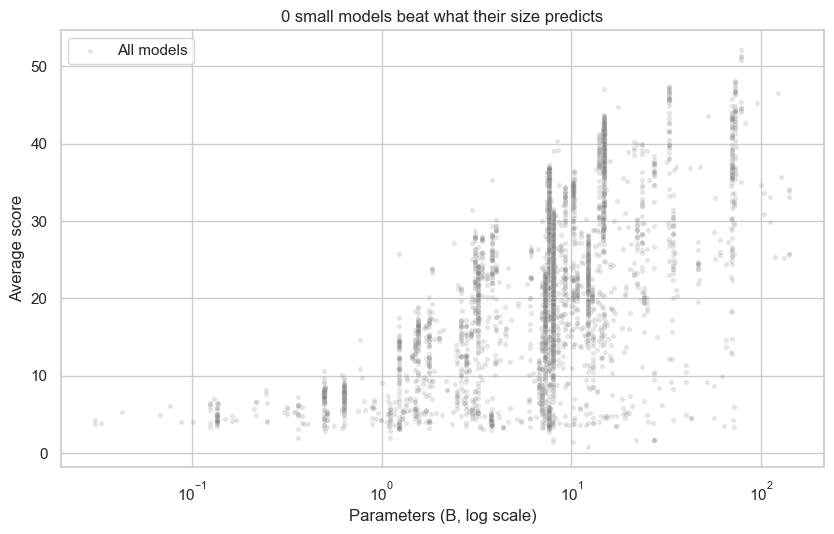

In [15]:
plt.figure(figsize=(8.5, 5.5))
sns.scatterplot(data=size, x=params_col, y=avg_col, alpha=0.2, s=14, color="grey", label="All models")
sns.scatterplot(data=small_overperf, x=params_col, y=avg_col, color="red", s=40, label="Unusually strong for size")
plt.xscale("log")
plt.xlabel("Parameters (B, log scale)"); plt.ylabel("Average score")
plt.title(f"{len(small_overperf)} small models beat what their size predicts")
plt.tight_layout(); plt.savefig("images/5_anomalies.png", dpi=150); plt.show()

In [16]:
# D) Do the anomalies cluster by model family, and does the leaderboard's own "Flagged" column agree?
top_uneven = clean[clean["z_spread"] > clean["z_spread"].mean() + 3*clean["z_spread"].std()]

base_col = find_col(df, "base model")
if base_col is not None:
    print("Imbalanced-profile models by base model (top 10):")
    display(top_uneven[base_col].value_counts().head(10))

flag_col = find_col(df, "flagged")
if flag_col is not None:
    share = lambda s: 100 * s.astype(float).mean()
    print(f"Flagged by the leaderboard: all models {share(clean[flag_col]):.1f}% | "
          f"IQR outliers {share(clean.loc[iqr_flags.any(axis=1), flag_col]):.1f}% | "
          f"imbalanced profiles {share(top_uneven[flag_col]):.1f}%")

Imbalanced-profile models by base model (top 10):


Base Model
Removed                                                5
microsoft/phi-4                                        5
Qwen/Qwen2.5-14B                                       2
1024m/PHI-4-Hindi                                      1
Azure99/Blossom-V6-14B (Merge)                         1
Danielbrdz/Barcenas-14b-phi-4 (Merge)                  1
LeroyDyer/_Spydaz_Web_AI_AGI_R1_Top_Student (Merge)    1
NeverSleep/Lumimaid-v0.2-12B                           1
NyxKrage/Microsoft_Phi-4                               1
Orion-zhen/phi-4-abliterated (Merge)                   1
Name: count, dtype: int64

Flagged by the leaderboard: all models 0.0% | IQR outliers 0.0% | imbalanced profiles 0.0%


### Possible explanations (not conclusions)
For each flagged model, the possible reasons include: fine-tuning on data close to the test set (contamination), a genuine training-recipe improvement, merged models inheriting strengths, or a data/reporting error. The data alone cannot tell these apart; check the model card and training data before concluding anything.

## 5) Numbers for the README and CV

In [17]:
# union, so a model flagged by both methods is counted once
anomalous = set(iqr_flags.index[iqr_flags.any(axis=1)]) | set(small_overperf.index)

summary = {
    "Raw records": len(raw),
    "Clean records": len(clean),
    "Benchmarks analyzed": len(bench),
    "Integrity issues (sum across checks; one row can be counted twice)": int(integrity["Issues found"].sum()),
    "Anomalous models (IQR or small-model overperformer, unique)": len(anomalous),
    "  of which IQR outliers": n_iqr_models,
    "Small-model overperformers": len(small_overperf),
    "Imbalanced-profile models": n_uneven,
    "Size vs score (Spearman rho)": round(rho, 2),
}
pd.Series(summary)

Raw records                                                           4576.00
Clean records                                                         4497.00
Benchmarks analyzed                                                      6.00
Integrity issues (sum across checks; one row can be counted twice)      91.00
Anomalous models (IQR or small-model overperformer, unique)            250.00
  of which IQR outliers                                                250.00
Small-model overperformers                                               0.00
Imbalanced-profile models                                               64.00
Size vs score (Spearman rho)                                             0.63
dtype: float64

In [18]:
print(f"AI Benchmark Data Analysis | Python, Pandas, SciPy, Matplotlib, Seaborn — Validated {len(raw):,} model records "
      f"across {len(bench)} benchmarks (found {n_dups} duplicate entries and {n_size + n_tiny} invalid or implausible sizes), "
      f"analyzed benchmark correlations ({strongest[0]}-{strongest[1]} rho={pairs.iloc[-1]:.2f}) and the size-vs-score trend (rho={rho:.2f}), "
      f"and flagged {n_iqr_models} IQR outliers and {n_uneven} imbalanced-profile models; documented findings in an executive summary.")

AI Benchmark Data Analysis | Python, Pandas, SciPy, Matplotlib, Seaborn — Validated 4,576 model records across 6 benchmarks (found 79 duplicate entries and 12 invalid or implausible sizes), analyzed benchmark correlations (BBH-MMLU-PRO rho=0.95) and the size-vs-score trend (rho=0.63), and flagged 250 IQR outliers and 64 imbalanced-profile models; documented findings in an executive summary.


## Executive Summary
I treated the Open LLM Leaderboard like a benchmark report under review. Of 4,576 model entries, the reported averages matched my own recalculation exactly and no score was missing or outside 0-100, so the scoring itself is consistent. The data-quality problems are in the metadata: 79 duplicate model names, 10 entries with a missing or zero size, and two entries whose reported size (a few million parameters) is implausible and distorted my first anomaly search until I excluded them.

BBH and MMLU-PRO move together almost perfectly (rho 0.95), while IFEval and MUSR are the least related (rho 0.37), so a single average hides very different skill profiles. Bigger models score higher overall (rho 0.63), but the gain is not constant: the median rises from about 8 points under 3B parameters to about 37 at 13-35B, then stops improving (about 36 at 35-80B; the over-80B group has only 16 models, so I would not draw conclusions from it). Fine-tuned, chat and merged models all score well above base models, whose median is lowest.

Most statistical outliers (250 models) come from MATH Lvl 5 and GPQA, where the score distribution has a long upper tail, so they reflect specialisation rather than errors. A further 64 models have very uneven profiles, and at least 11 of the 15 most extreme are variants of the same base model (Phi-4: strong on GPQA, weak on IFEval), which shows these are family effects, not 64 independent surprises. None of this proves contamination or error; the model cards and training data need to be checked before concluding anything.